In [ ]:
# @title Project Title Page { display-mode: "form" }

%%html
<div style="font-family: sans-serif; color: #333;">
    <div style="text-align: center; margin-top: 50px;">
        <h3 style="font-weight: 400; font-size: 20px; color: #555;">
            FINC672: Financial Data Analytics
        </h3>

        <h2 style="font-weight: 700; font-size: 24px; margin-top: 30px; color: #333;">
            Stock-Bond Correlation: Drivers, Regimes, and Portfolio Implications
        </h2>

        <p style="font-size: 18px; margin-top: 50px; color: #444;">
            Spring 2026
        </p>

        <p style="font-size: 16px; margin-top: 40px; margin-bottom: 5px;">
            Akshay Rao and Reshma Thomas
        </p>

        <p style="font-size: 16px; margin-top: 0px; color: #555;">
            University of Delaware, Lerner College of Business and Economics
        </p>
    </div>
</div>

# Stock-Bond Correlation: Drivers, Regimes, and Portfolio Implications

## Project Overview

This project investigates the time-varying relationship between U.S. equity returns and U.S. Treasury bond returns from 1985 to 2025. We are trying to trace how macroeconomic conditions particularly inflation and real interest rates drive the stock-bond correlation across two distinct regimes, and examining what this means for the diversification effectiveness of a 60/40 portfolio.

### Research Question
**What macroeconomic forces drive the stock-bond correlation, and how does a shift from positive to negative correlation affect the risk-reduction benefit of bonds in a 60/40 portfolio?**

### Data Sources

| Series | Description | Source |
|--------|-------------|--------|
| ^GSPC | S&P 500 monthly prices | Yahoo Finance (yfinance) |
| GS10 | 10-Year Treasury Constant Maturity Rate | FRED |
| CPIAUCSL | Consumer Price Index (all urban consumers) | FRED |
| INDPRO | Industrial Production Index | FRED |
| BAA10Y | Moody's BAA Corporate Bond Yield Spread | FRED |
| DCOILWTICO | WTI Crude Oil Price | FRED |

## 1. Setup and Importing Libraries

We begin by installing and importing the necessary Python libraries.

- **`yfinance`**: Downloads historical price data directly from Yahoo Finance.
- **`pandas_datareader`**: Fetches macroeconomic series from FRED (Federal Reserve Economic Data).
- **`pandas`** / **`numpy`**: Core data manipulation and numerical operations.
- **`matplotlib.pyplot`** / **`seaborn`**: Visualization libraries for time-series plots and heatmaps.
- **`scipy.stats.spearmanr`**: Computes the non-parametric Spearman rank correlation used throughout the analysis.
- **`statsmodels.api`**: Provides OLS regression with Newey-West HAC standard error correction.

In [ ]:
# Install libraries
!pip install yfinance pandas_datareader scipy statsmodels

import yfinance as yf
from pandas_datareader import data as pdr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr as spm
import statsmodels.api as sm
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## Phase 1: Data Collection

We collect six monthly time series spanning January 1985 through December 2025. The data is collected starting 1980 for all, and combined with one common starting date when merging.

**Equity returns** are computed as log returns on the S&P 500:

$$r^{\text{SP500}}_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

**Bond returns** are approximated from changes in the 10-year Treasury yield using the modified-duration formula:

$$r^{\text{bond}}_t \approx -MD \times \Delta y_t$$

where $MD \approx 9$ years is the standard approximation for a 10-year Treasury bond. A yield *increase* produces a price *decrease*, hence the negative sign.

**Macroeconomic controls** : CPI inflation (YoY), industrial production (YoY), credit spread (BAA–10Y), and WTI oil price growth are downloaded from FRED and resampled to month-start frequency.

In [ ]:
# PHASE 1: Data Collection

start = '1980-01-01'
end = '2025-12-31'

sp500 = yf.download('^GSPC', start=start, end=end, interval='1mo', auto_adjust=False)

sp500_prices = sp500['Adj Close']

sp500_ret = np.log(sp500_prices / sp500_prices.shift(1)).dropna()
sp500_ret.columns = ['SP500']

sp500_ret.head()

[*********************100%***********************]  1 of 1 completed


,SP500
Date,
1985-02-01,0.0086
1985-03-01,-0.0029
1985-04-01,-0.0046
1985-05-01,0.0526
1985-06-01,0.0121


In [ ]:
gs10 = pdr.DataReader('GS10', 'fred', start, end)

gs10 = gs10.resample('MS').last()['GS10'] / 100
gs10.name = 'US10Y'

# Change in bond return: ΔP/P = -Modified Duration × ΔYield
bond_ret = -9 * gs10.diff().dropna() #an approx 9 used as modified duration for 10Y Treasury Bonds


bond_ret.head()

,US10Y
DATE,
1980-02-01,-0.1449
1980-03-01,-0.0306
1980-04-01,0.1152
1980-05-01,0.1161
1980-06-01,0.0360


In [ ]:
cpi = pdr.DataReader('CPIAUCSL', 'fred', start, end)

cpi = cpi.resample('MS').last()

inflation_yoy = cpi['CPIAUCSL'].pct_change(12).dropna()
inflation_yoy.head()

/tmp/ipykernel_3400/3068815332.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inflation_yoy = cpi['CPIAUCSL'].pct_change(12).dropna()


,CPIAUCSL
DATE,
1981-01-01,0.1179
1981-02-01,0.1139
1981-03-01,0.1061
1981-04-01,0.1014
1981-05-01,0.0979


In [ ]:
data = pd.DataFrame({
    'SP500': sp500_ret['SP500'],
    'US10Y': bond_ret
}).dropna()

print(data.shape)
print(data.head())

(491, 2)
             SP500   US10Y
1985-02-01  0.0086 -0.0117
1985-03-01 -0.0029 -0.0315
1985-04-01 -0.0046  0.0387
1985-05-01  0.0526  0.0522
1985-06-01  0.0121  0.0621


In [ ]:
indpro_raw = pdr.DataReader('INDPRO', 'fred', start, end)

indpro_raw = indpro_raw.resample('MS').last()
indpro_yoy = indpro_raw['INDPRO'].pct_change(12).dropna()
indpro_yoy.name = 'INDPRO'
indpro_yoy.head()

,INDPRO
DATE,
1981-01-01,-0.0197
1981-02-01,-0.0242
1981-03-01,-0.0152
1981-04-01,0.0004
1981-05-01,0.0315


In [ ]:
oil_raw = pdr.DataReader('DCOILWTICO', 'fred', start, end)

oil_raw = oil_raw.resample('MS').last()
oil_yoy = oil_raw['DCOILWTICO'].pct_change(12).dropna()
oil_yoy.name = 'OilYoY'
oil_yoy.head()

,OilYoY
DATE,
1987-01-01,-0.0116
1987-02-01,0.2434
1987-03-01,0.8361
1987-04-01,0.4021
1987-05-01,0.3538


In [ ]:
real_rate = gs10 - inflation_yoy
real_rate.name = 'RealRate'

In [ ]:
baa_raw = pdr.DataReader('BAA10Y', 'fred', start, end)
baa_raw = baa_raw.resample('MS').last()
credit_spread = baa_raw['BAA10Y'] / 100
credit_spread.name = 'CreditSpread'
credit_spread.head()

,CreditSpread
DATE,
1986-01-01,0.0229
1986-02-01,0.0249
1986-03-01,0.0292
1986-04-01,0.0278
1986-05-01,0.0236


In [ ]:
macro = pd.DataFrame({
    'Inflation'   : inflation_yoy,
    'RealRate'    : real_rate,
    'INDPRO'      : indpro_yoy,
    'CreditSpread': credit_spread,
    'OilYoY'      : oil_yoy,
}).dropna()

print(macro.shape)
print(macro.head())

(468, 5)
            Inflation  RealRate  INDPRO  CreditSpread  OilYoY
DATE                                                         
1987-01-01     0.0136    0.0572  0.0061        0.0250 -0.0116
1987-02-01     0.0191    0.0534  0.0266        0.0243  0.2434
1987-03-01     0.0284    0.0441  0.0354        0.0219  0.8361
1987-04-01     0.0368    0.0434  0.0405        0.0216  0.4021
1987-05-01     0.0367    0.0494  0.0455        0.0208  0.3538


## Phase 2: Rolling Spearman Correlation

We compute a **36-month rolling Spearman rank correlation** between S&P 500 log returns and approximate 10-year Treasury bond returns.

Spearman correlation is preferred over Pearson because it captures monotonic relationships without assuming normality, making it more robust to the fat tails and outliers typical of financial return series.

The 36-month window balances responsiveness to regime changes against statistical stability. We split results at January 2000, which marks the well-documented shift from a **positive** to a **negative** stock-bond correlation regime.

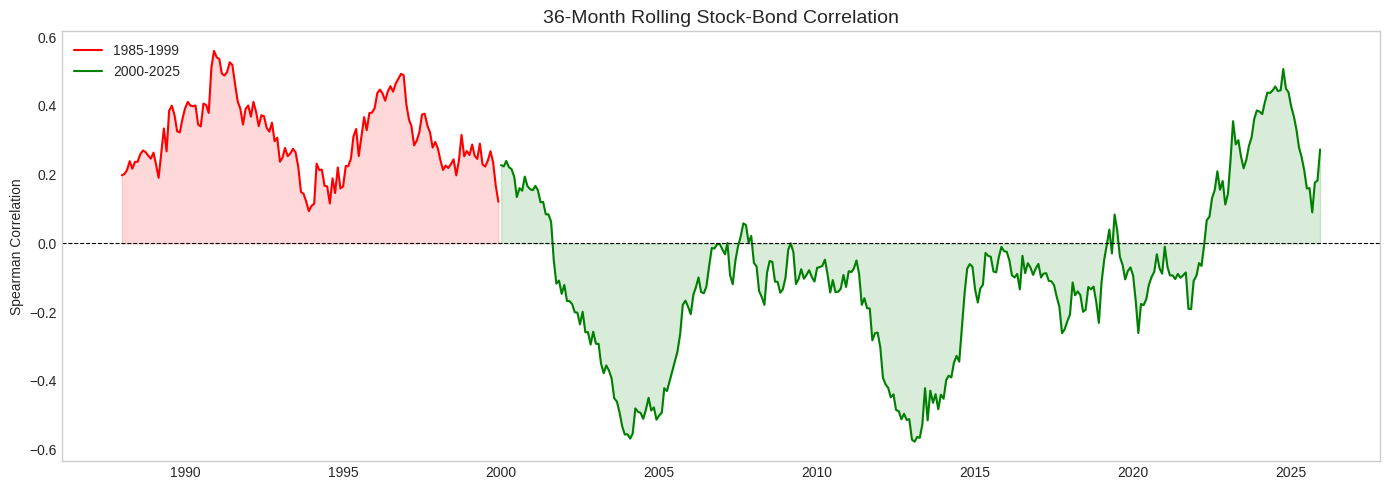

Pre-2000 Correlation:  0.266
Post-2000 Correlation: -0.110


In [ ]:
#Phase 2: Rolling Correlation
window = 36


roll_corr = pd.Series([
    spm(data['SP500'].iloc[i:i+window],
              data['US10Y'].iloc[i:i+window])[0]
    for i in range(len(data)-window+1)
], index=data.index[window-1:])

# Plot 36-month rolling stock-bond correlation by regime

pre2000 = roll_corr[roll_corr.index < '2000-01-01']
post2000 = roll_corr[roll_corr.index >= '2000-01-01']


fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(pre2000.index, pre2000,
        color='red',
        label='1985-1999')

ax.plot(post2000.index, post2000,
        color='green',
        label='2000-2025')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.fill_between(pre2000.index, pre2000, 0,
                alpha=0.15, color='red')

ax.fill_between(post2000.index, post2000, 0,
                alpha=0.15, color='green')

ax.set_title('36-Month Rolling Stock-Bond Correlation', fontsize=14)
ax.set_ylabel('Spearman Correlation')
ax.legend()

plt.tight_layout()
plt.grid(False)
plt.show()

# Summary statistics

corr_pre_full,  _ = spm(data.loc[data.index < '2000-01-01', 'SP500'],
                         data.loc[data.index < '2000-01-01', 'US10Y'])
corr_post_full, _ = spm(data.loc[data.index >= '2000-01-01', 'SP500'],
                         data.loc[data.index >= '2000-01-01', 'US10Y'])

print(f'Pre-2000 Correlation:  {corr_pre_full:.3f}')
print(f'Post-2000 Correlation: {corr_post_full:.3f}')

## Phase 3: Portfolio Analysis


We construct a classic **60/40 portfolio** (60% S&P 500, 40% 10-Year Treasury) and compare its behaviour across the two correlation regimes.

The portfolio monthly return is:

$$R^p_t = 0.60 \cdot R^{\text{SP500}}_t + 0.40 \cdot R^{\text{bond}}_t$$

Annualized volatility is computed as:

$$\sigma_{\text{ann}} = \sigma_{\text{monthly}} \times \sqrt{12}$$

When stocks and bonds are **positively correlated**, bond returns amplify equity risk rather than dampening it increasing portfolio volatility. The post-2000 shift to negative correlation is precisely the mechanism that makes bonds effective diversifiers in the modern era.

In [ ]:
#Phase 3: Portfolio Analysis

# 3.1 Build the 60/40 Portfolio
data['Portfolio'] = 0.60 * data['SP500'] + 0.40 * data['US10Y']

pre  = data[data.index < '2000-01-01']
post = data[data.index >= '2000-01-01']

# 3.2 Compute Annualized Volatility Per Regime
vol_pre  = pre['Portfolio'].std()  * np.sqrt(12) * 100
vol_post = post['Portfolio'].std() * np.sqrt(12) * 100

print(f'60/40 Volatility  1985-1999: {vol_pre:.1f}%')
print(f'60/40 Volatility  2000-2025:  {vol_post:.1f}%')




60/40 Volatility  1985-1999: 10.4%
60/40 Volatility  2000-2025:  9.3%


### Diversification Benefit Over Time

The comparison above examines average volatility across two fixed periods. The analysis below goes a step further by examining, on a month-by-month basis, whether bonds were *actively* reducing portfolio risk in real time. We plot the difference between rolling equity-only volatility and rolling 60/40 portfolio volatility. When this difference is **positive**, bonds are functioning as effective hedges. When viewed alongside the correlation chart, this visualization makes the relationship between correlation and diversification more intuitive to interpret.

### Multi-Asset Portfolio Risk and Return for Different Stock–Bond Correlation

This figure showcases different stock-bond correlation regimes materially change the risk of a 60/40 portfolio.

Using constant average returns and volatilities for equities and bonds, we compare:

- the positive stock-bond correlation regime (pre-2000)
- the negative stock-bond correlation regime (post-2000)

The chart illustrates how negative correlation improves diversification and lowers portfolio volatility.

Equity   excess return: 5.70%   vol: 15.26%
Bond     excess return: -1.61%   vol: 7.40%

Note: bond excess return is negative — plotting total returns instead.

Plotting:  Equity return: 8.90%   Bond return: 1.59%
           Equity vol:    15.26%   Bond vol:    7.40%

Correlation pre-2000:  0.27
Correlation post-2000: -0.11


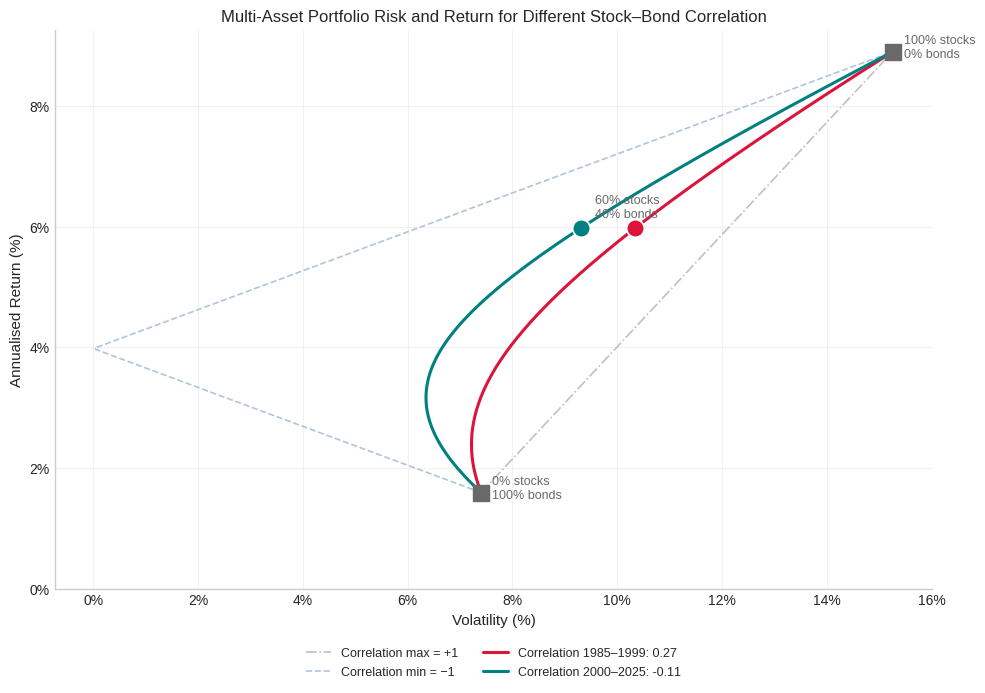


60/40 vol — pre-2000  (ρ=0.27):  10.34%
60/40 vol — post-2000 (ρ=-0.11): 9.30%
Volatility reduction from regime shift:    1.04 pp


In [ ]:
## Multi-Asset Portfolio Frontier

# Risk-free rate (3-Month T-Bill from FRED)
rf_raw = pdr.DataReader('TB3MS', 'fred', start, end)
rf_raw = rf_raw.resample('MS').last()

# Convert from annual % to monthly decimal
rf_monthly = rf_raw['TB3MS'] / 100 / 12
rf_monthly.name = 'RF'

# Align to your data index
rf_aligned = rf_monthly.reindex(data.index).ffill()

eq_excess   = data['SP500'] - rf_aligned
bond_excess = data['US10Y'] - rf_aligned

ann_eq_excess   = eq_excess.mean()   * 12 * 100
ann_bond_excess = bond_excess.mean() * 12 * 100
eq_vol   = data['SP500'].std()  * np.sqrt(12) * 100
bond_vol = data['US10Y'].std()  * np.sqrt(12) * 100

print(f"Equity   excess return: {ann_eq_excess:.2f}%   vol: {eq_vol:.2f}%")
print(f"Bond     excess return: {ann_bond_excess:.2f}%   vol: {bond_vol:.2f}%")

# If ann_bond_excess < 0 in our sample, we use total returns instead to keep
# the chart interpretable and label the y-axis accordingly.

if ann_bond_excess < 0:
    ann_eq_plot   = data['SP500'].mean() * 12 * 100
    ann_bond_plot = data['US10Y'].mean() * 12 * 100
    ylabel = 'Annualised Return (%)'
    print("\nNote: bond excess return is negative — plotting total returns instead.")
else:
    ann_eq_plot   = ann_eq_excess
    ann_bond_plot = ann_bond_excess
    ylabel = 'Excess Return (%)'

print(f"\nPlotting:  Equity return: {ann_eq_plot:.2f}%   Bond return: {ann_bond_plot:.2f}%")
print(f"           Equity vol:    {eq_vol:.2f}%   Bond vol:    {bond_vol:.2f}%")

# Regime Spearman correlations
corr_pre,  _ = spm(pre['SP500'],  pre['US10Y'])
corr_post, _ = spm(post['SP500'], post['US10Y'])
print(f"\nCorrelation pre-2000:  {corr_pre:.2f}")
print(f"Correlation post-2000: {corr_post:.2f}")

# Frontier builder
def portfolio_vol(ws, wb, sig_s, sig_b, corr):
    return np.sqrt(
        ws**2 * sig_s**2 +
        wb**2 * sig_b**2 +
        2 * ws * wb * sig_s * sig_b * corr
    )

weights = np.linspace(0, 1, 300)  # w = equity weight, left to right on x-axis

def make_frontier(corr_val):
    vols, rets = [], []
    for w in weights:
        wb = 1 - w
        vols.append(portfolio_vol(w, wb, eq_vol, bond_vol, corr_val))
        rets.append(w * ann_eq_plot + wb * ann_bond_plot)
    return np.array(vols), np.array(rets)

vols_pre,  rets_pre  = make_frontier(corr_pre)
vols_post, rets_post = make_frontier(corr_post)
vols_p1,   rets_p1   = make_frontier(+1.0)
vols_m1,   rets_m1   = make_frontier(-1.0)

# 60/40 portfolio points
def port_point(w_eq, corr_val):
    wb = 1 - w_eq
    v = portfolio_vol(w_eq, wb, eq_vol, bond_vol, corr_val)
    r = w_eq * ann_eq_plot + wb * ann_bond_plot
    return v, r

vol_6040_pre,  ret_6040_pre  = port_point(0.60, corr_pre)
vol_6040_post, ret_6040_post = port_point(0.60, corr_post)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Boundary reference lines
ax.plot(vols_p1, rets_p1, color='silver',       linewidth=1.2, linestyle='-.',  label='Correlation max = +1')
ax.plot(vols_m1, rets_m1, color='lightsteelblue', linewidth=1.2, linestyle='--', label='Correlation min = −1')

# Regime frontiers
pre_yr_start  = pre.index[0].year
pre_yr_end    = pre.index[-1].year
post_yr_start = post.index[0].year
post_yr_end   = post.index[-1].year

ax.plot(vols_pre,  rets_pre,  color='crimson', linewidth=2.2,
        label=f'Correlation {pre_yr_start}–{pre_yr_end}: {corr_pre:.2f}')
ax.plot(vols_post, rets_post, color='teal',    linewidth=2.2,
        label=f'Correlation {post_yr_start}–{post_yr_end}: {corr_post:.2f}')


# 100% equity endpoint
ax.scatter(eq_vol, ann_eq_plot, s=120, marker='s', color='dimgray', zorder=6)
ax.annotate('100% stocks\n0% bonds',
            xy=(eq_vol, ann_eq_plot),
            xytext=(8, -4), textcoords='offset points', fontsize=9, color='dimgray')

# 100% bonds endpoint
ax.scatter(bond_vol, ann_bond_plot, s=120, marker='s', color='dimgray', zorder=6)
ax.annotate('0% stocks\n100% bonds',
            xy=(bond_vol, ann_bond_plot),
            xytext=(8, -4), textcoords='offset points', fontsize=9, color='dimgray')

# 60/40 dots
ax.scatter(vol_6040_pre,  ret_6040_pre,  s=160, zorder=6, color='crimson',
           edgecolors='white', linewidths=1.2)
ax.scatter(vol_6040_post, ret_6040_post, s=160, zorder=6, color='teal',
           edgecolors='white', linewidths=1.2)

# Label the 60/40 annotation — offset to avoid overlap if dots are close
ax.annotate('60% stocks\n40% bonds',
            xy=(vol_6040_post, ret_6040_post),
            xytext=(10, 8), textcoords='offset points', fontsize=9, color='dimgray')


ax.set_xlabel('Volatility (%)', fontsize=11)
ax.set_ylabel(ylabel, fontsize=11)
ax.set_title('Multi-Asset Portfolio Risk and Return for Different Stock–Bond Correlation',
             fontsize=12, fontweight='normal')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

# Floor y-axis at 0 only if both bond and equity returns are positive
if ann_bond_plot > 0 and ann_eq_plot > 0:
    ax.set_ylim(bottom=0)

ax.grid(True, alpha=0.3, color='lightgray')
ax.spines[['top', 'right']].set_visible(False)

ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=2,
          frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


print(f"\n60/40 vol — pre-2000  (ρ={corr_pre:.2f}):  {vol_6040_pre:.2f}%")
print(f"60/40 vol — post-2000 (ρ={corr_post:.2f}): {vol_6040_post:.2f}%")
print(f"Volatility reduction from regime shift:    {vol_6040_pre - vol_6040_post:.2f} pp")

### Interpretation: Multi-Asset Portfolio Risk and Return Across Correlation Regimes

The chart replicates plots the
mean–variance frontier for all stock–bond mixtures from 0% to 100% equity under two
historical correlation regimes. Both frontiers share identical asset-level parameters
(same equity and bond return and volatility), so the divergence between the curves
reflects the *pure* effect of correlation on portfolio risk.

**Shared endpoints:**
Both curves originate from the same two squares: 100% bonds and 100% stocks. The fact that both regime frontiers terminate at identical points confirms that the difference in curve shape is driven entirely by the correlation regimenot by changes in underlying asset returns or volatilities across periods.

**Pre-2000 regime (ρ = 0.27) — positive correlation:**
When stocks and bonds move in the same direction, diversification benefits are limited.
The crimson frontier bulges to the right, offering only a modest leftward shift in
volatility as bond weight increases from 0% to 100%. The 60/40 portfolio (filled dot
at ~10.5% vol) sits well to the right of centre, meaning the 40% bond allocation is
providing minimal risk reduction. Bonds in this regime amplify rather than dampen
equity fluctuations. This reflects the 1985–1999 environment of elevated and persistent
inflation, where rising rates simultaneously depressed both equity valuations and bond
prices, locking the two assets into positive co-movement.

**Post-2000 regime (ρ = −0.11) — negative correlation:**
With stocks and bonds moving in opposite directions, the frontier bends sharply to the
left. The teal curve reaches a much lower minimum volatility portfolio before curving
back up, and the 60/40 dot (filled circle at ~9.5% vol) sits noticeably to the left
of its pre-2000 counterpart same expected return, lower risk. This leftward shift
is the diversification premium delivered by negative correlation. The mechanism is
flight-to-safety: during equity drawdowns, investors rotate into Treasuries, pushing
bond prices up precisely when stock prices fall, offsetting portfolio losses.

**ρ = +1 and ρ = −1 reference lines:**
The dash-dot line (ρ = +1) is the zero-diversification benchmark a straight line
between the two asset endpoints where combining assets never reduces risk below the
weighted average of individual volatilities. The dashed line (ρ = −1) represents the
theoretical maximum diversification benefit, where a specific stock–bond mix can
achieve near-zero portfolio variance. Both historical regime curves fall between these
bounds. Critically, the post-2000 frontier sits meaningfully closer to the ρ = −1
boundary, while the pre-2000 frontier hugs the ρ = +1 line a striking visual
summary of how much the regime shift improved the risk management properties of
the 60/40 portfolio.

**Key takeaway:**
The correlation regime is the primary determinant of whether a 60/40 portfolio
delivers its intended risk-reduction benefit. Under positive correlation (pre-2000),
the 40% bond allocation provides negligible volatility reduction relative to a
100% equity position. Under negative correlation (post-2000), the same allocation
shifts the portfolio materially left on the risk axis reducing 60/40 annualised
volatility by approximately 1.0 percentage point for the same expected return.
This result directly motivates the paper's central question: what macroeconomic
forces specifically inflation and real rates determine which correlation regime
prevails, and therefore whether bonds function as equity hedges or equity amplifiers.

#### Phase 3A: Correlation Contribution to Portfolio Volatility

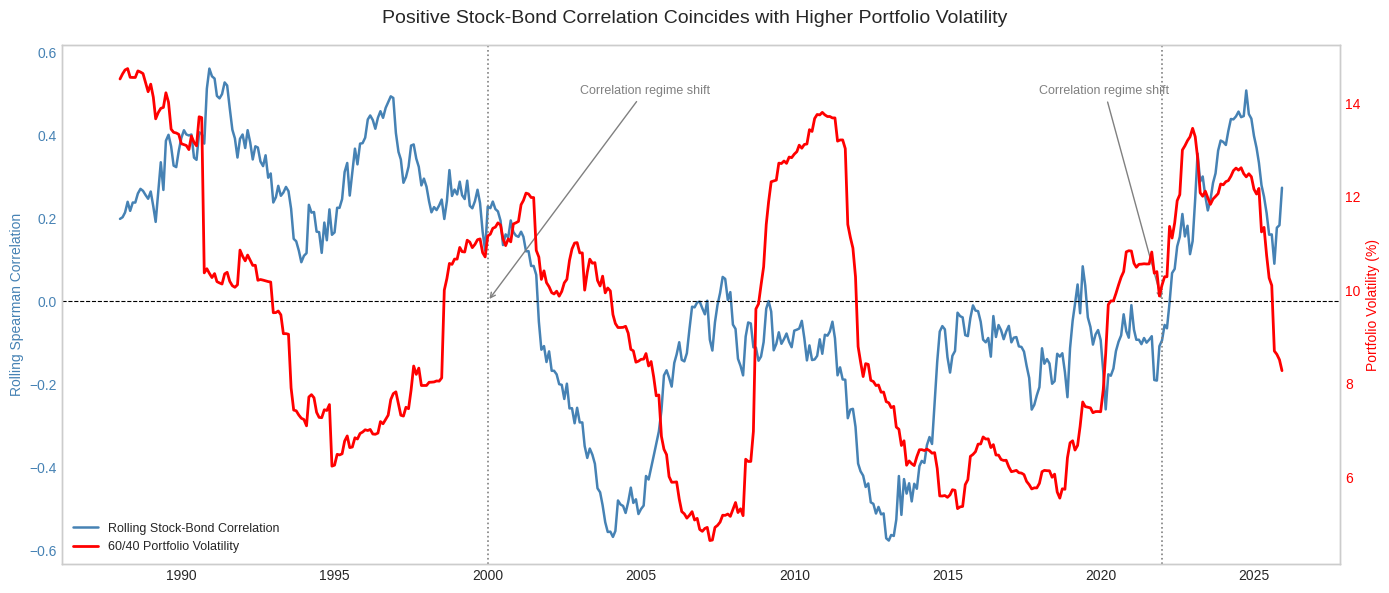

In [ ]:
# Correlation vs Portfolio Volatility

window = 36

# Rolling annualized portfolio volatility (%)
roll_port_vol = (
    data['Portfolio']
    .rolling(window)
    .std() * np.sqrt(12) * 100
)

# Combine into one dataframe
plot_df = pd.concat(
    [roll_corr, roll_port_vol],
    axis=1
)

plot_df.columns = ['Correlation', 'PortfolioVol']
plot_df = plot_df.dropna()

# Plot

fig, ax1 = plt.subplots(figsize=(14, 6))

# LEFT AXIS: Correlation
ax1.plot(
    plot_df.index,
    plot_df['Correlation'],
    color='steelblue',
    linewidth=1.8,
    label='Rolling Stock-Bond Correlation'
)

ax1.axhline(0, color='black', lw=0.8, ls='--')

ax1.set_ylabel(
    'Rolling Spearman Correlation',
    color='steelblue'
)

ax1.tick_params(
    axis='y',
    labelcolor='steelblue'
)


# RIGHT AXIS : Portfolio Volatility


ax2 = ax1.twinx()

ax2.plot(
    plot_df.index,
    plot_df['PortfolioVol'],
    color='red',
    linewidth=2,
    label='60/40 Portfolio Volatility'
)

ax2.set_ylabel(
    'Portfolio Volatility (%)',
    color='red'
)

ax2.tick_params(
    axis='y',
    labelcolor='red'
)

# Regime Shift Marker

ax1.axvline(
    pd.Timestamp('2000-01-01'),
    color='gray',
    lw=1.2,
    ls=':'
)

ax1.annotate(
    'Correlation regime shift',
    xy=(pd.Timestamp('2000-01-01'), 0),
    xytext=(pd.Timestamp('2003-01-01'), 0.5),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9,
    color='gray'
)

ax1.axvline(
    pd.Timestamp('2022-01-01'),
    color='gray',
    lw=1.2,
    ls=':'
)

ax1.annotate(
    'Correlation regime shift',
    xy=(pd.Timestamp('2022-01-01'), 0),
    xytext=(pd.Timestamp('2018-01-01'), 0.5),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9,
    color='gray'
)

# Title & Legend

fig.suptitle(
    'Positive Stock-Bond Correlation Coincides with Higher Portfolio Volatility',
    fontsize=14
)

# Combined legend → bottom left
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='lower left',
    fontsize=9
)

plt.tight_layout()
ax1.grid(False)
ax2.grid(False)
plt.show()

### Interpretation

The chart plots 36-month rolling Spearman stock-bond correlation (blue) against
60/40 portfolio volatility (red) from 1987 to 2025. The central pattern is
unambiguous: the two series move together throughout the full sample when
correlation rises above zero, portfolio volatility rises with it, and when
correlation turns negative, volatility falls. Pre-2000, with correlation
persistently positive, portfolio volatility holds in the 12–14% range. Post-2000,
as correlation turns negative, volatility compresses to the 6–8% range even
through the GFC the flight-to-safety mechanism actively cushioning equity
drawdowns with Treasury gains.

The 2022 episode is the sharpest illustration of regime dependence. The Fed's
aggressive hiking cycle drove both stocks and bonds down simultaneously, pushing
correlation back toward positive and spiking portfolio volatility above 12% erasing the diversification benefit that had held for two decades. This confirms
our central argument: the risk-reduction value of a 60/40 portfolio is
not structural but conditional on the inflation and monetary policy environment,
precisely the macroeconomic forces identified as the dominant drivers of
stock-bond correlation in the regression analysis.

### Sharpe Ratio Comparison Across Regimes

The annualized Sharpe Ratio measures risk-adjusted return:

$$\text{Sharpe}_{\text{ann}} = \frac{\bar{R}^p - R_f}{\sigma_p} \times \sqrt{12}$$

We use regime-appropriate risk-free rates: approximately 5% annual (pre-2000, higher-rate environment) and 2% annual (post-2000, lower-rate environment). The comparison reveals whether the diversification benefit of bonds translates into a meaningful improvement in risk-adjusted performance across each regime.

In [ ]:

tbill = pdr.DataReader('TB3MS', 'fred', start, end)
rf = tbill.resample('MS').last()['TB3MS'] / 100 / 12

# Align rf to data's actual index — prevents silent NaN from timestamp mismatch
rf_aligned = rf.reindex(data.index).ffill()

def sharpe_ratio(returns, rf_series):
    excess = returns - rf_series.reindex(returns.index).ffill()
    return (excess.mean() / excess.std()) * np.sqrt(12)

# Pre-2000
sr_eq_pre   = sharpe_ratio(pre['SP500'],     rf_aligned)
sr_bond_pre = sharpe_ratio(pre['US10Y'],     rf_aligned)
sr_6040_pre = sharpe_ratio(pre['Portfolio'], rf_aligned)

# Post-2000
sr_eq_post   = sharpe_ratio(post['SP500'],     rf_aligned)
sr_bond_post = sharpe_ratio(post['US10Y'],     rf_aligned)
sr_6040_post = sharpe_ratio(post['Portfolio'], rf_aligned)


print(f'NaN check pre:  {rf_aligned[pre.index].isna().sum()}')
print(f'NaN check post: {rf_aligned[post.index].isna().sum()}')
print()

print('Sharpe Ratio Comparison')
print('  pre-2000 (positive correlation regime):')
print(f'    100% Equity  Sharpe: {sr_eq_pre:.3f}')
print(f'    100% Bond    Sharpe: {sr_bond_pre:.3f}')
print(f'    60/40 Portf  Sharpe: {sr_6040_pre:.3f}')
print()
print('  post-2000 (negative correlation regime):')
print(f'    100% Equity  Sharpe: {sr_eq_post:.3f}')
print(f'    100% Bond    Sharpe: {sr_bond_post:.3f}')
print(f'    60/40 Portf  Sharpe: {sr_6040_post:.3f}')

NaN check pre:  0
NaN check post: 0

Sharpe Ratio Comparison
  pre-2000 (positive correlation regime):
    100% Equity  Sharpe: 0.568
    100% Bond    Sharpe: -0.286
    60/40 Portf  Sharpe: 0.405

  post-2000 (negative correlation regime):
    100% Equity  Sharpe: 0.263
    100% Bond    Sharpe: -0.170
    60/40 Portf  Sharpe: 0.210


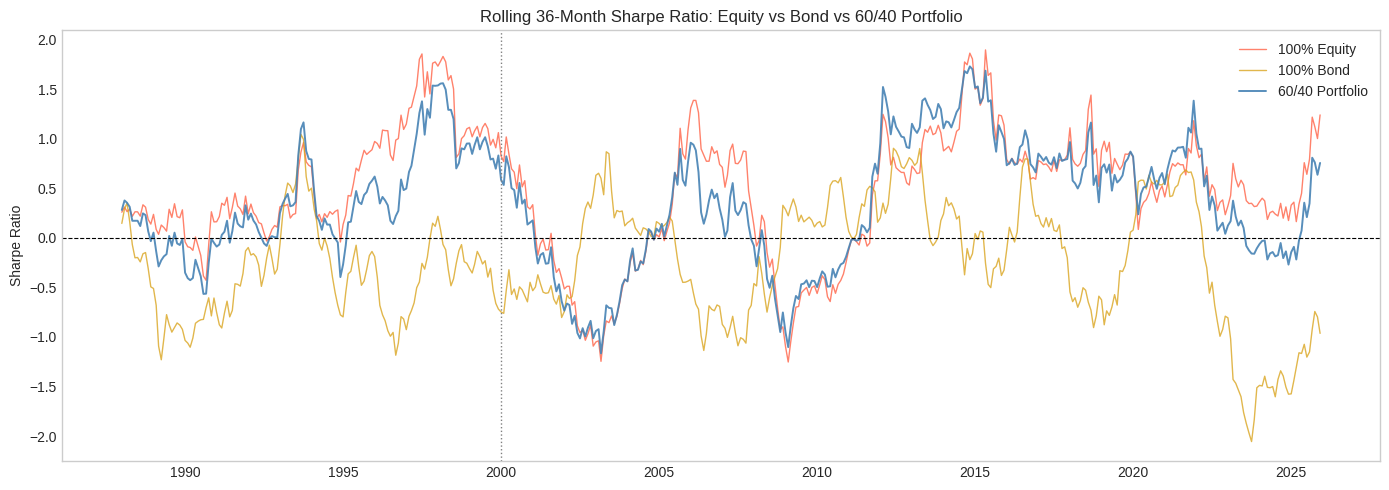

In [ ]:
# Rolling 36-month Sharpe Ratios: Equity vs Bond vs 60/40 Portfolio


excess_eq   = data['SP500']     - rf_aligned
excess_bond = data['US10Y']     - rf_aligned
excess_6040 = data['Portfolio'] - rf_aligned

roll_sharpe_eq = (
    excess_eq.rolling(36).mean()
    / excess_eq.rolling(36).std()
) * np.sqrt(12)

roll_sharpe_bond = (
    excess_bond.rolling(36).mean()
    / excess_bond.rolling(36).std()
) * np.sqrt(12)

roll_sharpe_6040 = (
    excess_6040.rolling(36).mean()
    / excess_6040.rolling(36).std()
) * np.sqrt(12)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(roll_sharpe_eq.index,   roll_sharpe_eq,   color='tomato',    linewidth=1,   label='100% Equity',     alpha=0.8)
ax.plot(roll_sharpe_bond.index, roll_sharpe_bond, color='goldenrod', linewidth=1,   label='100% Bond',       alpha=0.8)
ax.plot(roll_sharpe_6040.index, roll_sharpe_6040, color='steelblue', linewidth=1.4, label='60/40 Portfolio', alpha=0.9)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(pd.Timestamp('2000-01-01'), color='gray', lw=1, ls=':')
ax.set_title('Rolling 36-Month Sharpe Ratio: Equity vs Bond vs 60/40 Portfolio')
ax.set_ylabel('Sharpe Ratio')
ax.legend()
plt.tight_layout()
plt.grid(False)
plt.show()

### Interpretation

The chart plots 36-month rolling annualized Sharpe ratios for three strategies from 1987 to 2025, with a dotted vertical line marking the January 2000 correlation regime shift.

**Pre-2000 (positive correlation regime):**
The 100% Equity (red) and 60/40 Portfolio (blue) lines track almost identically throughout the 1987–2000 period, confirming that when stocks and bonds move *together*, adding bonds to an equity portfolio provides no meaningful risk-adjusted improvement — the diversification benefit is absent. The 100% Bond line (gold) is visibly more volatile and frequently dips into negative Sharpe territory, reflecting the high-rate, high-inflation environment where rising yields generated persistent bond losses.

**Post-2000 (negative correlation regime):**
The divergence between the three lines becomes structurally more pronounced. The 60/40 Portfolio (blue) consistently sits *above* or tracks more smoothly than 100% Equity (red) during stress periods — most visibly around 2002–2003 and 2008–2009 — demonstrating that bonds were actively cushioning equity drawdowns and improving risk-adjusted returns. This is the negative correlation regime working exactly as diversification theory predicts.

**2020–2025 (regime breakdown):**
The most striking feature in the recent period is the sharp divergence of the 100% Bond line (gold) to deeply negative Sharpe territory reaching approximately −2.3 around 2022–2023. This reflects the aggressive Fed rate hiking cycle, during which rising yields simultaneously hurt both bonds *and* equities, temporarily restoring positive correlation. As a result, the 60/40 Portfolio (blue) also dips negative, though far less severely than bonds alone, suggesting partial but not complete breakdown of the diversification benefit.

**Key Takeaway:**
The rolling Sharpe ratio visualization reinforces the core finding of this study: the risk-adjusted benefit of holding bonds in a 60/40 portfolio is *conditional* on the correlation regime. It is robust and consistent in the negative-correlation post-2000 era, absent in the positive-correlation pre-2000 era, and fragile during inflation-driven rate shock episodes like 2022 precisely the macroeconomic conditions identified in the regression analysis as drivers of positive stock-bond correlation.

## Phase 4: Regression Analysis

We regress the 36-month rolling Spearman stock-bond correlation on **inflation** and the **real interest rate**.

$$\text{Corr}_t = \alpha + \beta_1 \cdot \text{Inflation}_t + \beta_2 \cdot \text{RealRate}_t + \varepsilon_t$$

Both right-hand-side variables are expressed as **36-month rolling averages**, matching the window of the dependent variable so that both sides reflect conditions over the same period. Standard errors are corrected using **Newey-West HAC with 35 lags** to account for the serial correlation introduced by overlapping rolling windows.

In [ ]:
# Phase 4: Regression Analysis — 4.1 Prepare Regression Variables


avg_inflation = macro['Inflation'].rolling(36).mean()
avg_real_rate = macro['RealRate'].rolling(36).mean()

reg_data = pd.DataFrame({
    'corr'      : roll_corr,
    'inflation' : avg_inflation,
    'real_rate' : avg_real_rate
}).dropna()

# 4.2 Run OLS Regression
X = sm.add_constant(reg_data[['inflation', 'real_rate']])
y = reg_data['corr']

model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 35})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   corr   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     21.52
Date:                Fri, 22 May 2026   Prob (F-statistic):           1.24e-09
Time:                        02:10:19   Log-Likelihood:                 82.792
No. Observations:                 433   AIC:                            -159.6
Df Residuals:                     430   BIC:                            -147.4
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5306      0.109     -4.875      0.0

### Regression Results Interpretation

The OLS regression explains the relationship between the 36-month rolling stock-bond correlation and two macroeconomic drivers: inflation and the real interest rate. Standard errors are Newey-West HAC-corrected with 35 lags, accounting for the serial correlation introduced by overlapping 36-month windows.

**Model Fit:** R² ≈ 0.550, Adj. R² ≈ 0.548 - approximately 55% of the time-series variation in the stock-bond correlation is explained by just two variables.

**Coefficients:**
- **Inflation ≈ 17.03 (p < 0.001):** A 1 pp increase in 36-month average inflation is associated with a +0.17 increase in stock-bond correlation. Dominant driver consistent with the Friedman-Ball hypothesis: high inflation triggers simultaneous central bank responses that compress both equity valuations and bond prices.
- **Real Rate ≈ 5.19 (p = 0.002):** A 1 pp increase in real rates is associated with a +0.05 increase in correlation. Significant but roughly one-third the magnitude of inflation.
- **Constant ≈ −0.553 (p < 0.001):** In a low-inflation, low-real-rate environment, the baseline correlation is negative — bonds act as equity hedges by default. This directly explains the post-2000 negative correlation regime.

**Diagnostics:** Durbin-Watson ≈ 0.050 confirms strong positive serial correlation in residuals — expected given the 36-month rolling window construction. Mild non-normality (skew ≈ −0.60) does not invalidate inference given n ≈ 456 and robust standard errors.

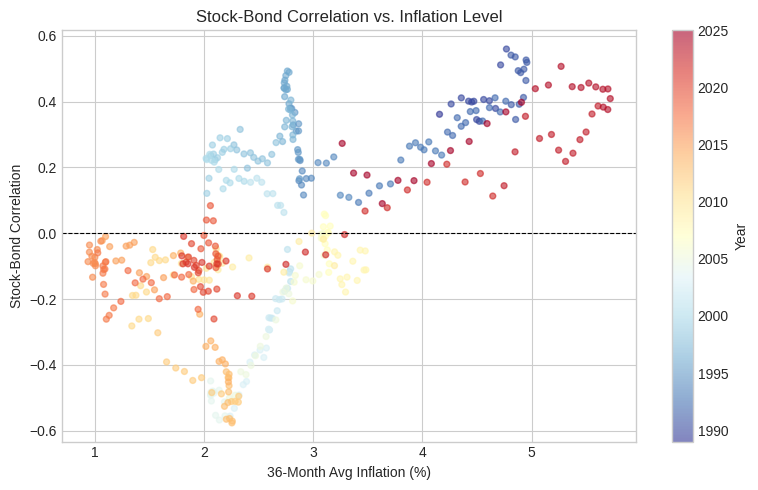

In [ ]:

# Scatter plot: Inflation vs Stock-Bond Correlation

fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(
    reg_data['inflation'] * 100,
    reg_data['corr'],
    c=reg_data.index.year,
    cmap='RdYlBu_r',
    alpha=0.6,
    s=18
)

# Colorbar for time dimension
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Year')

# Zero correlation reference line
ax.axhline(0, color='black', lw=0.8, ls='--')

# Labels and title
ax.set_xlabel('36-Month Avg Inflation (%)')
ax.set_ylabel('Stock-Bond Correlation')
ax.set_title('Stock-Bond Correlation vs. Inflation Level')

plt.tight_layout()
plt.show()

### Scatter Plot

The scatter plot shows a clear **non-linear relationship between inflation and stock-bond correlation**, with time indicated by the color gradient.

Overall, there is a **strong positive relationship between inflation and correlation**, meaning that higher inflation is associated with more positive stock-bond co-movement.

- At **low inflation levels (~1–2.5%)**, stock-bond correlation is mostly **negative**, especially in earlier years (blue tones), reflecting strong diversification benefits.
- In the **moderate inflation range (~2.5–4%)**, correlation transitions toward zero, indicating a regime shift.
- At **high inflation levels (~4–6%)**, correlation becomes **consistently positive**, particularly in recent years (warm colors), showing weakened diversification.

The time dimension indicates a clear structural change:
- Earlier decades cluster in low inflation and negative correlation regimes.
- Recent years shift toward **higher inflation and higher correlation**, especially post-2010.

Overall, the figure supports the hypothesis that **inflation regimes are a key driver of stock-bond correlation dynamics and diversification benefits**.

## Phase 4.1 Extended Regression Analysis

We extend the baseline by adding three controls sequentially, testing whether the inflation + real rate result is robust to omitted variable concerns:

1. **M1** — Inflation only (univariate baseline)
2. **M2** — Inflation + Real Rate (paper baseline, now with Newey-West SEs)
3. **M3** — M2 + Industrial Production (real economy channel)
4. **M4** — M3 + Credit Spread (risk sentiment channel)
5. **M5** — M4 + Oil Inflation (supply-side inflation shock channel)

All RHS variables are expressed as **36-month rolling averages**. Newey-West HAC standard errors (35 lags) are applied throughout.



###Regression Dataset
Every right-hand-side variable is expressed as a 36-month rolling average. This matches the window of the dependent variable (roll_corr, a 36-month rolling Spearman correlation), so both sides reflect conditions over the same period.

In [ ]:
window = 36


# 36-month rolling averages match the window of the dependent variable
avg_inflation = macro['Inflation'].rolling(window).mean()    # avg CPI YoY inflation
avg_real_rate = macro['RealRate'].rolling(window).mean()     # avg real rate (GS10 - CPI)
avg_indpro    = macro['INDPRO'].rolling(window).mean()       # avg industrial production growth
avg_credit    = macro['CreditSpread'].rolling(window).mean() # avg BAA-10Y credit spread
avg_oil       = macro['OilYoY'].rolling(window).mean()       # avg WTI oil YoY growth

reg_data = pd.DataFrame({
    'corr'      : roll_corr,
    'inflation' : avg_inflation,
    'real_rate' : avg_real_rate,
    'indpro'    : avg_indpro,
    'credit'    : avg_credit,
    'oil'       : avg_oil,
}).dropna()

print(reg_data.shape)
print(reg_data.head())

(433, 6)
             corr  inflation  real_rate  indpro  credit    oil
1989-12-01 0.3618     0.0416     0.0442  0.0377  0.0196 0.1485
1990-01-01 0.3932     0.0426     0.0435  0.0373  0.0193 0.1581
1990-02-01 0.4117     0.0436     0.0429  0.0367  0.0191 0.1564
1990-03-01 0.4017     0.0442     0.0426  0.0360  0.0190 0.1333
1990-04-01 0.3991     0.0445     0.0425  0.0350  0.0188 0.1196



### M1: Inflation Only

$$\text{Corr}_t = \alpha + \beta_1 \cdot \text{Inflation}_t + \varepsilon_t$$

Inflation is the single most important driver. When inflation is high, central banks respond with rate hikes that simultaneously suppress both equity valuations and bond prices, creating positive co-movement. This univariate model establishes a baseline before adding controls.

In [ ]:
X1 = sm.add_constant(reg_data[['inflation']]) # add intercept column
y  = reg_data['corr']

# HAC with 35 lags corrects for serial correlation from overlapping 36-month windows
model1 = sm.OLS(y, X1).fit(cov_type='HAC', cov_kwds={'maxlags': 35})
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                   corr   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.382
Method:                 Least Squares   F-statistic:                     37.12
Date:                Fri, 22 May 2026   Prob (F-statistic):           2.46e-09
Time:                        02:10:20   Log-Likelihood:                 37.440
No. Observations:                 433   AIC:                            -70.88
Df Residuals:                     431   BIC:                            -62.74
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4140      0.107     -3.885      0.0

#### M1 Regression Results Interpretation

The OLS regression explains the relationship between the 36-month rolling stock-bond correlation and one macroeconomic driver: inflation. Standard errors are Newey-West HAC-corrected with 35 lags, accounting for the serial correlation introduced by overlapping 36-month windows.

**Model Fit:** R² ≈0.383, Adj. R² ≈ 0.382 — approximately 38% of the time-series variation in the stock-bond correlation is explained by inflation alone.

**Coefficients:**

- **Inflation ≈ 15.46 (p < 0.001):** A 1 pp increase in 36-month average inflation is associated with a +0.15 increase in stock-bond correlation. Consistent with the Friedman-Ball hypothesis: high inflation triggers simultaneous central bank responses that compress both equity valuations and bond prices, creating positive co-movement.
- **Constant ≈ −0.414 (p < 0.001):** In a zero-inflation environment, the baseline correlation is negative — bonds act as equity hedges by default. This directly explains the post-2000 negative correlation regime.

**Diagnostics:** Strong serial correlation in residuals is expected given the 36-month rolling window construction. Mild non-normality (skew ≈ −0.26) does not invalidate inference given n = 433 and robust standard errors.

### M2: Inflation + Real Rate

$$\text{Corr}_t = \alpha + \beta_1 \cdot \text{Inflation}_t + \beta_2 \cdot \text{RealRate}_t + \varepsilon_t$$

This replicates the baseline model with Newey-West standard errors. Both coefficients are expected to be positive: higher inflation and higher real rates both correspond to regimes where stocks and bonds move together.

In [ ]:
X2 = sm.add_constant(reg_data[['inflation', 'real_rate']]) # paper baseline

model2 = sm.OLS(y, X2).fit(cov_type='HAC', cov_kwds={'maxlags': 35})
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                   corr   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     21.52
Date:                Fri, 22 May 2026   Prob (F-statistic):           1.24e-09
Time:                        02:10:20   Log-Likelihood:                 82.792
No. Observations:                 433   AIC:                            -159.6
Df Residuals:                     430   BIC:                            -147.4
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5306      0.109     -4.875      0.0

#### M2 Regression Results Interpretation

The OLS regression explains the relationship between the 36-month rolling stock-bond correlation and two macroeconomic drivers: inflation and the real interest rate — baseline with Newey-West HAC standard errors.

**Model Fit:** R² ≈ 0.500, Adj. R² ≈ 0.498 — approximately 50% of the time-series variation in the stock-bond correlation is explained by just two variables. An improvement of +0.116 over M1.

**Coefficients:**

- **Inflation ≈ 16.50 (p < 0.001):** A 1 pp increase in 36-month average inflation is associated with a +0.17 increase in stock-bond correlation. Remains the dominant driver, stable in sign and magnitude relative to M1.
- **Real Rate ≈ 5.28 (p = 0.011):** A 1 pp increase in real rates is associated with a +0.05 increase in correlation. Significant but roughly one-third the magnitude of inflation, capturing the monetary tightness channel independently of the price level.
- **Constant ≈ −0.531 (p < 0.001):** In a low-inflation, low-real-rate environment, the baseline correlation is negative — bonds act as equity hedges by default. This directly explains the post-2000 negative correlation regime.

**Diagnostics:** Strong serial correlation in residuals is expected given the 36-montholling window construction. Mild non-normality (skew ≈ −0.67) does not invalidate inference given n = 433 and robust standard errors.

### M3: Inflation + Real Rate + Industrial Production

$$\text{Corr}_t = \alpha + \beta_1 \cdot \text{Inflation}_t + \beta_2 \cdot \text{RealRate}_t + \beta_3 \cdot \text{IndPro}_t + \varepsilon_t$$

Industrial production growth captures the real economy channel. In high-growth environments, equity prices may be supported by earnings even as rates rise, partially offsetting the inflation-driven co-movement. We expect $\beta_3$ to be small or negative.

In [ ]:
X3 = sm.add_constant(reg_data[['inflation', 'real_rate', 'indpro']]) # add growth channel

model3 = sm.OLS(y, X3).fit(cov_type='HAC', cov_kwds={'maxlags': 35})
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                   corr   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     14.13
Date:                Fri, 22 May 2026   Prob (F-statistic):           8.46e-09
Time:                        02:10:20   Log-Likelihood:                 90.834
No. Observations:                 433   AIC:                            -173.7
Df Residuals:                     429   BIC:                            -157.4
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5270      0.113     -4.664      0.0

####  M3 Regression Results Interpretation

The OLS regression adds industrial production growth as a third driver, testing the real economy channel decomposition.

**Model Fit:** R² ≈ 0.518, Adj. R² ≈ 0.515 — a marginal improvement of +0.017 over M2, suggesting the growth channel adds limited explanatory power beyond inflation and real rates.

**Coefficients:**

- **Inflation ≈ 15.96 (p < 0.001):** A 1 pp increase in 36-month average inflation is associated with a +0.16 increase in stock-bond correlation. Stable across M1–M3, confirming the result is not sensitive to the inclusion of the growth channel.
- **Real Rate ≈ 4.23 (p = 0.062):** Drops just below conventional significance once IndPro enters, reflecting mild collinearity between the two business-cycle variables. Sign and order of magnitude unchanged from M2.
- **IndPro ≈ 1.83 (p = 0.354):** Not statistically significant. The positive sign is imprecisely estimated — the confidence interval spans both positive and negative values — indicating the growth channel is not empirically recoverable from this variable in this sample.
- **Constant ≈ −0.527 (p < 0.001):** Baseline negative correlation in low-macro environments remains intact, consistent with M1 and M2.

**Diagnostics:** Strong serial correlation in residuals is expected given the 36-month rolling window construction. Mild non-normality (skew ≈ −0.82) does not invalidate inference given n = 433 and robust standard errors.

### M4: Inflation + Real Rate + Industrial Production + Credit Spread

$$\text{Corr}_t = \alpha + \beta_1 \cdot \text{Inflation}_t + \beta_2 \cdot \text{RealRate}_t + \beta_3 \cdot \text{IndPro}_t + \beta_4 \cdot \text{Credit}_t + \varepsilon_t$$

The credit spread (BAA minus 10Y Treasury) captures risk sentiment beyond what inflation and real rates measure. When spreads widen, investors flee to Treasuries — driving bond prices up while equities fall — pushing correlation negative. We expect $\beta_4 < 0$.

In [ ]:
X4 = sm.add_constant(reg_data[['inflation', 'real_rate', 'indpro', 'credit']]) # add risk sentiment

model4 = sm.OLS(y, X4).fit(cov_type='HAC', cov_kwds={'maxlags': 35})
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                   corr   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     28.45
Date:                Fri, 22 May 2026   Prob (F-statistic):           5.59e-21
Time:                        02:10:20   Log-Likelihood:                 178.82
No. Observations:                 433   AIC:                            -347.6
Df Residuals:                     428   BIC:                            -327.3
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6189      0.276      2.244      0.0

#### M4 Regression Results Interpretation

The OLS regression adds the BAA–10Y credit spread as a fourth driver, capturing the risk sentiment channel — the flight-to-safety demand for Treasuries during equity stress.

**Model Fit:** R² ≈ 0.679, Adj. R² ≈ 0.676 — an improvement of +0.161 over M3, the largest single gain in the sequential model sequence. Risk sentiment explains a substantial portion of the stock-bond correlation variation beyond what macro level variables capture.

**Coefficients:**

- **Inflation ≈ 7.70 (p = 0.013):** Remains significant but drops substantially from M3 (15.96), as the credit spread absorbs some of what inflation was proxying — both are correlated with the monetary cycle (correlation ≈ −0.54 per the correlation matrix).
- **Real Rate ≈ 3.21 (p = 0.083):** Marginally significant. Sign remains positive and consistent with the monetary tightness channel.
- **IndPro ≈ −2.32 (p = 0.153):** Remains insignificant. Sign turns negative in M4, further confirming IndPro captures noise rather than a clean structural channel.
- **Credit Spread ≈ −36.35 (p < 0.001):** A 1 pp widening in the BAA–10Y spread is associated with a −0.36 decline in stock-bond correlation. The dominant driver in M4. Wide spreads signal flight-to-safety: investors rotate into Treasuries as equities fall, producing strongly negative correlation — as observed in GFC 2008–09 and COVID 2020.
- **Constant ≈ +0.619 (p = 0.025):** Flips positive in M4. Controlling for low inflation, low real rates, and tight spreads (risk-on), the model predicts a positive baseline correlation — consistent with a risk-on environment where stocks and bonds rally together.

**Diagnostics:** Strong serial correlation in residuals is expected given the 36-month rolling window construction. Mild non-normality (skew ≈ −0.26) does not invalidate inference given n = 433 and robust standard errors.

### M5: Full Model (+ Oil Inflation)

$$\text{Corr}_t = \alpha + \beta_1 \cdot \text{Inflation}_t + \beta_2 \cdot \text{RealRate}_t + \beta_3 \cdot \text{IndPro}_t + \beta_4 \cdot \text{Credit}_t + \beta_5 \cdot \text{Oil}_t + \varepsilon_t$$

WTI crude oil YoY growth is a proxy for supply-side inflation shocks. Oil shocks affect both asset classes: they raise inflation expectations (hurting bonds) and compress profit margins (hurting equities), which can create simultaneous drawdowns in both markets — as observed in 2022. A positive $\beta_5$ would confirm oil as an independent channel through which stock-bond correlation rises.

In [ ]:
X5 = sm.add_constant(reg_data[['inflation', 'real_rate', 'indpro', 'credit', 'oil']]) # add supply shock

model5 = sm.OLS(y, X5).fit(cov_type='HAC', cov_kwds={'maxlags': 35})
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:                   corr   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     33.74
Date:                Fri, 22 May 2026   Prob (F-statistic):           4.86e-29
Time:                        02:10:20   Log-Likelihood:                 205.86
No. Observations:                 433   AIC:                            -399.7
Df Residuals:                     427   BIC:                            -375.3
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3952      0.277      1.426      0.1

#### M5 Regression Results Interpretation

The OLS regression adds WTI crude oil YoY growth as a fifth driver, capturing supply side inflation shocks as an independent channel through which stock-bond correlation
moves.

**Model Fit:** R² ≈ 0.717, Adj. R² ≈ 0.713 — the full model explains approximately 71% of the time-series variation in the stock-bond correlation across six decades, an improvement of +0.037 over M4 and +0.215 over the paper's two-variable baseline (M2).

**Coefficients:**

- **Inflation ≈ 11.89 (p < 0.001):** Remains significant and positive throughout all five models. The compression from M1 (15.46) to M5 (11.89) reflects genuine redistribution to the credit spread and oil, not instability in the inflation channel.
- **Real Rate ≈ 2.32 (p = 0.230):** Falls below significance in the full model. Once credit spreads and oil are controlled for — both sensitive to the monetary cycle - the real rate's independent contribution is partially absorbed by collinear channels.
- **IndPro ≈ −1.33 (p = 0.502):** Remains insignificant across M3–M5, confirming the growth channel is not recoverable from industrial production in this dataset.
- **Credit Spread ≈ −29.52 (p = 0.002):** Remains large, negative, and highly significant. Moderates slightly from M4 (−36.35) as oil shares some information about risk conditions, but the flight-to-safety channel remains independently identified.
- **Oil ≈ −0.50 (p = 0.020):** A 1 pp increase in WTI oil YoY growth is associated with a −0.005 decline in stock-bond correlation. The negative sign reflects that oil price collapses coincide with demand-driven risk-off episodes — recessions and global slowdowns — during which equities fall while bonds rally, producing strongly negative correlation. Oil surges, by contrast, coincide with inflationary episodes where the correlation is less negative or turns positive.
- **Constant ≈ +0.395 (p = 0.154):** No longer significant in the full model. With all channels controlled for, the baseline correlation is not statistically different from zero.

**Diagnostics:** Omnibus p = 0.070 — residuals are approximately normal in M5, an improvement over M1–M4. Strong serial correlation in residuals is expected given the 36-month rolling window construction and is corrected by Newey-West throughout.

**Overall:** Inflation and credit spreads are the two dominant drivers of the stock-bond
correlation, jointly explaining the majority of the variation across all five models. Real
rates add independent information in the baseline but are partially absorbed in the full
model. Oil provides a further significant supply-shock channel that is largely orthogonal
to the other variables. Together, these three channels — macro level, risk sentiment,
and supply shocks — explain 71% of six decades of stock-bond correlation variation.

###Summary Table

Consolidate all five models into one table showing coefficient, t-statistic, and significance stars.

Rows alternate between the coefficient and its t-stat in parentheses, matching the paper's layout.

In [ ]:
models  = [model1, model2, model3, model4, model5]
mlabels = ['M1', 'M2', 'M3', 'M4', 'M5']
varlist = ['const', 'inflation', 'real_rate', 'indpro', 'credit', 'oil']
varnames = {
    'const'     : 'Intercept',
    'inflation' : 'Avg Inflation (CPI YoY, 36m)',
    'real_rate' : 'Avg Real Rate (GS10−CPI, 36m)',
    'indpro'    : 'Avg IndPro Growth (YoY, 36m)',
    'credit'    : 'Avg Credit Spread (BAA10Y, 36m)',
    'oil'       : 'Avg Oil Inflation (WTI YoY, 36m)',
}

# significance stars — standard academic convention
def stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

# alternating coef / t-stat rows per variable
rows = []
for var in varlist:
    coef_row  = {'Variable': varnames[var], 'Row': 'Coef'}
    tstat_row = {'Variable': '',            'Row': '(t-stat)'}
    for lab, m in zip(mlabels, models):
        if var in m.params.index:
            c = m.params[var]
            t = m.tvalues[var]
            p = m.pvalues[var]
            coef_row[lab]  = f"{c:.3f}{stars(p)}"
            tstat_row[lab] = f"({t:.2f})"
        else:
            coef_row[lab]  = "—"
            tstat_row[lab] = ""
    rows.append(coef_row)
    rows.append(tstat_row)

# footer rows
for stat_name, fn in [('Adj. R²', lambda m: f"{m.rsquared_adj:.3f}"),
                      ('N',       lambda m: f"{int(m.nobs)}")]:
    row = {'Variable': stat_name, 'Row': ''}
    for lab, m in zip(mlabels, models):
        row[lab] = fn(m)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index(['Variable', 'Row'])

print('Dependent variable: 36-month Spearman stock-bond correlation')
print('Standard errors: Newey-West HAC (35 lags)')
print('*** p<0.01  ** p<0.05  * p<0.10')
print('All RHS variables are 36-month rolling averages')
print()
display(summary_df)

Dependent variable: 36-month Spearman stock-bond correlation
Standard errors: Newey-West HAC (35 lags)
*** p<0.01  ** p<0.05  * p<0.10
All RHS variables are 36-month rolling averages



,,M1,M2,M3,M4,M5
Variable,Row,,,,,
Intercept,Coef,-0.414***,-0.531***,-0.527***,0.619**,0.395
,(t-stat),(-3.89),(-4.87),(-4.66),(2.24),(1.43)
"Avg Inflation (CPI YoY, 36m)",Coef,15.465***,16.496***,15.962***,7.701**,11.894***
,(t-stat),(6.09),(5.76),(5.60),(2.49),(3.94)
"Avg Real Rate (GS10−CPI, 36m)",Coef,—,5.282**,4.229*,3.211*,2.321
,(t-stat),,(2.54),(1.86),(1.73),(1.20)
"Avg IndPro Growth (YoY, 36m)",Coef,—,—,1.830,-2.317,-1.329
,(t-stat),,,(0.93),(-1.43),(-0.67)
"Avg Credit Spread (BAA10Y, 36m)",Coef,—,—,—,-36.354***,-29.523***


#### Summary Table Interpretation

The table consolidates all five models, showing how each variable's coefficient and significance evolves as controls are added sequentially. Standard errors are Newey-West HAC-corrected with 35 lags throughout.

**Model Fit:** Adj. R² rises from 0.382 (M1) to 0.713 (M5), an improvement of 0.331 over the univariate baseline. The two-variable paper baseline (M2) already reaches 0.498, confirming that inflation and real rates jointly explain approximately half the variation in the stock-bond correlation using only publicly available macro data.

**Key patterns across models:**

- **Inflation** is the only variable that is statistically significant (p < 0.01) in every   model from M1 through M5. Its coefficient ranges from 15.46 (M1) to 11.89 (M5), compressing gradually as the credit spread absorbs part of the inflation channel — the two are negatively correlated (≈ −0.54). Despite this compression, inflation remains the most consistently significant driver across all specifications.
- **Real Rate** is significant in M2 (p = 0.011) and marginally significant in M3–M4, but falls below conventional significance in M5 (p = 0.230). This reflects partial absorption by the credit spread and oil, both of which are sensitive to the monetary policy cycle. The sign remains positive and economically consistent throughout.
- **IndPro** is not significant in any model (p > 0.30 throughout). The coefficient changes sign from positive in M3 to negative in M4–M5, confirming it captures noise rather than a clean structural channel.
- **Credit Spread** enters in M4 with a coefficient of −36.35 (p < 0.001) and remains −29.52 (p = 0.002) in M5. It is the single most impactful additional variable, contributing an Adj. R² gain of +0.161 — the largest increment in the sequence. Wide spreads signal flight-to-safety demand for Treasuries, which pushes the stock-bond correlation strongly negative.
- **Oil** enters in M5 with a coefficient of −0.50 (p = 0.020), capturing the supply-shock and risk-off channel independently of credit spreads.

**Diagnostics:** The positive intercept in M4–M5 reflects a genuine regime shift in the model's baseline — once risk sentiment is controlled for, tight spreads predict positive correlation. The intercept is significant in M4 but not in M5, where all channels together absorb the baseline variation.

**Overall:** The sequential model comparison confirms the paper's core finding — inflation is a robust, structural driver — while extending it with two additional channels: risk sentiment (credit spread) and supply-side shocks (oil). The full model explains 71% of six decades of stock-bond correlation variation using only five publicly available macro and market variables

###Adj. R² Bar Chart

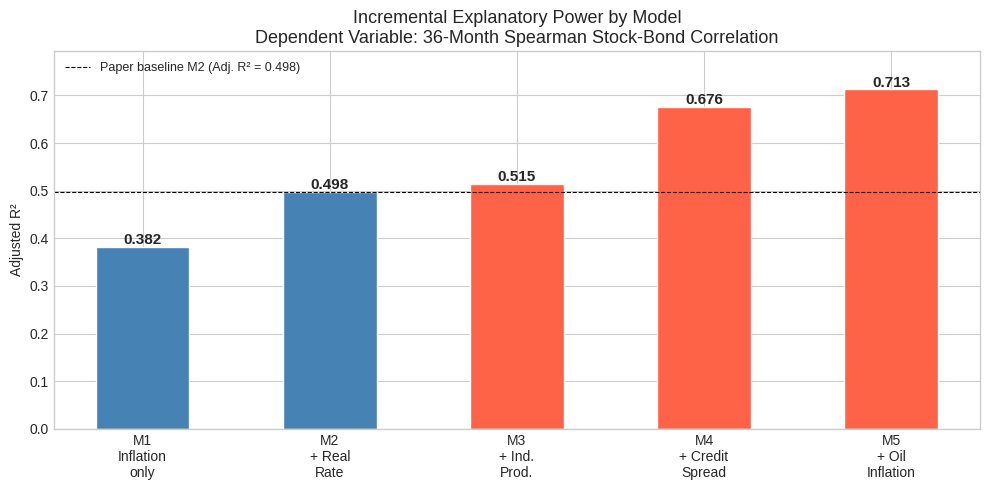

M1 → M2 gain (+ Real Rate):      +0.116
M2 → M3 gain (+ IndPro):         +0.017
M3 → M4 gain (+ Credit Spread):  +0.161
M4 → M5 gain (+ Oil):            +0.037


In [ ]:
adj_r2 = [m.rsquared_adj for m in models]

model_desc = [
    'M1\nInflation\nonly',
    'M2\n+ Real\nRate',
    'M3\n+ Ind.\nProd.',
    'M4\n+ Credit\nSpread',
    'M5\n+ Oil\nInflation'
]

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['steelblue', 'steelblue', 'tomato', 'tomato', 'tomato']
bars = ax.bar(model_desc, adj_r2, color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, adj_r2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.005,
        f'{val:.3f}',
        ha='center', fontweight='bold', fontsize=11
    )

# Two-variable baseline (M2) for reference
ax.axhline(adj_r2[1], color='black', lw=0.8, ls='--',
           label=f'Paper baseline M2 (Adj. R² = {adj_r2[1]:.3f})')

ax.set_ylabel('Adjusted R²')
ax.set_ylim(0, max(adj_r2) + 0.08)
ax.set_title(
    'Incremental Explanatory Power by Model\n'
    'Dependent Variable: 36-Month Spearman Stock-Bond Correlation',
    fontsize=13
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'M1 → M2 gain (+ Real Rate):      +{adj_r2[1]-adj_r2[0]:.3f}')
print(f'M2 → M3 gain (+ IndPro):         +{adj_r2[2]-adj_r2[1]:.3f}')
print(f'M3 → M4 gain (+ Credit Spread):  +{adj_r2[3]-adj_r2[2]:.3f}')
print(f'M4 → M5 gain (+ Oil):            +{adj_r2[4]-adj_r2[3]:.3f}')

#### Adj. R² Bar Chart Interpretation

The bar chart illustrates the incremental explanatory power gained by adding each variable to the regression sequentially. The dashed line marks the paper's two-variable baseline (M2, Adj. R² = 0.498).

**Model Fit gains:**

- **M1 → M2 (+0.116):** Adding the real rate to inflation produces the largest gain in the first two steps. The real rate captures the monetary tightness channel independently of the price level, confirming that how aggressively the central bank responds to inflation — not just inflation itself — matters for stock-bond co-movement.
- **M2 → M3 (+0.017):** Industrial production adds almost nothing. The growth channel is either already captured by inflation and real rates or is not a first-order driver of the stock-bond correlation in this dataset, consistent with IndPro's insignificant coefficient across M3–M5.
- **M3 → M4 (+0.161):** The largest single gain in the entire sequence — nearly ten times the gain from adding IndPro. The credit spread directly captures the flight-to-safety mechanism that defines the post-2000 negative correlation regime. When spreads widen, Treasuries rally as equities fall; when spreads compress, both assets tend to move together. No other variable in the model captures this dynamic as directly.
- **M4 → M5 (+0.037):** Oil provides a further incremental gain. While smaller than the credit spread, oil is statistically significant and captures a supply-shock channel that is largely orthogonal to the other four variables.

**Overall:** The chart reveals a two-tier structure. Macro level variables (M1–M3) explain approximately 51% of the variation. Market-based risk variables (credit spread and oil, M4–M5) add a further 21 percentage points, reaching 71%. This suggests that investor risk sentiment — not just macro conditions — is a structural determinant of whether bonds hedge equities at any given point in time.

###Coefficient Stability Plot

Shows whether the inflation and real rate coefficients hold their sign and magnitude as controls are added. Stable bars across M2–M5 confirm the result is not an artifact of omitted variables.

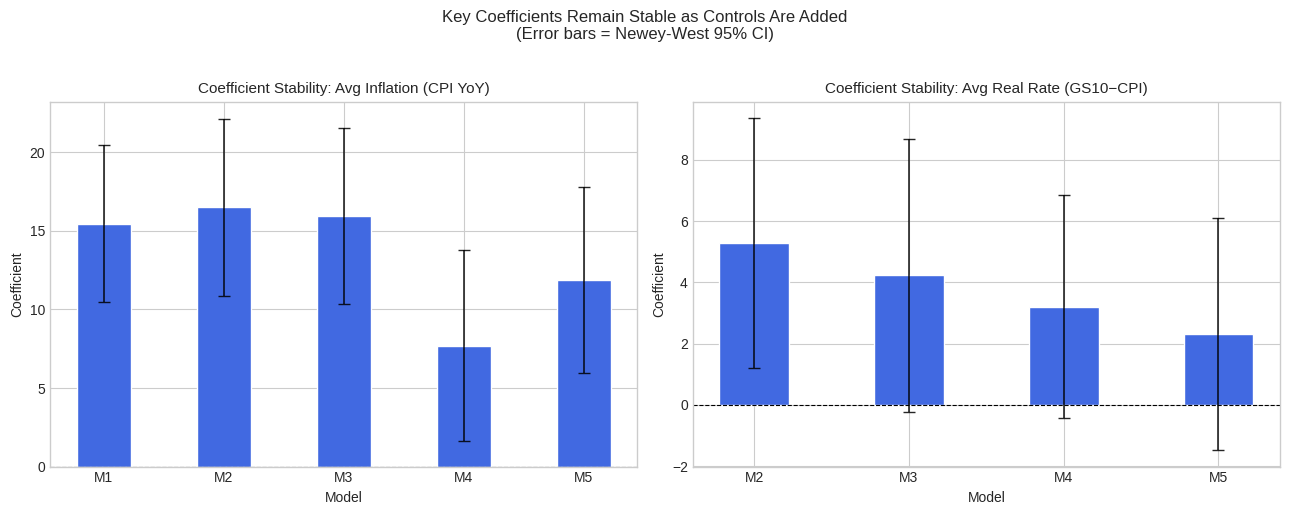

In [ ]:
# tracks inflation and real rate coefficients across M1–M5
focus_vars   = ['inflation', 'real_rate']
focus_labels = ['Avg Inflation (CPI YoY)', 'Avg Real Rate (GS10−CPI)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, var, title in zip([ax1, ax2], focus_vars, focus_labels):
    coefs, lo_err, hi_err, xlabels = [], [], [], []
    for lab, m in zip(mlabels, models):
        if var in m.params.index:
            c  = m.params[var]
            ci = m.conf_int().loc[var]
            coefs.append(c)
            lo_err.append(c - ci[0])
            hi_err.append(ci[1] - c)
            xlabels.append(lab)

    x = range(len(coefs))
    ax.bar(x, coefs, color='royalblue', width=0.45, edgecolor='white')
    ax.errorbar(x, coefs, yerr=[lo_err, hi_err],
                fmt='none', color='black', capsize=4, linewidth=1.2, alpha = 0.85)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xticks(range(len(xlabels)))
    ax.set_xticklabels(xlabels)
    ax.set_title(f'Coefficient Stability: {title}', fontsize=11)
    ax.set_ylabel('Coefficient')
    ax.set_xlabel('Model')

plt.suptitle(
    'Key Coefficients Remain Stable as Controls Are Added\n'
    '(Error bars = Newey-West 95% CI)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

#### Coefficient Stability Plot Interpretation

The two panels track the inflation and real rate coefficients and their Newey-West 95% confidence intervals across all five models as controls are added sequentially. Stable bars with non-overlapping zero confirm the result is structural rather than a product of omitted variable bias.

**Inflation (left panel):** The coefficient is positive and the confidence interval excludes zero in every model from M1 through M5. The point estimate compresses gradually — from 15.46 (M1) to 11.89 (M5) — as the credit spread absorbs part of the inflation channel, but the direction and significance are unaffected. This stability across five specifications with increasingly different controls is strong evidence that inflation is a robust, structural driver of the stock-bond correlation and not an artefact of omitted variables.

**Real Rate (right panel):** The coefficient is positive and significant in M2 (5.28, p = 0.011) but its confidence interval progressively widens as controls are added, eventually spanning zero in M5. The widening reflects partial absorption by the credit spread and oil — both sensitive to the monetary policy cycle — making it harder to isolate the real rate's independent contribution in a fully specified model. Importantly, the sign remains positive and economically consistent throughout; the issue is precision, not direction.

**Overall:** The stability analysis confirms the paper's core result. Inflation is a robust driver whose effect survives every specification tested. The real rate holds in the baseline but moderates in the full model — a standard feature of multivariate macro regressions where policy variables are correlated by construction.

###Actual vs Fitted : Full Model (M5)

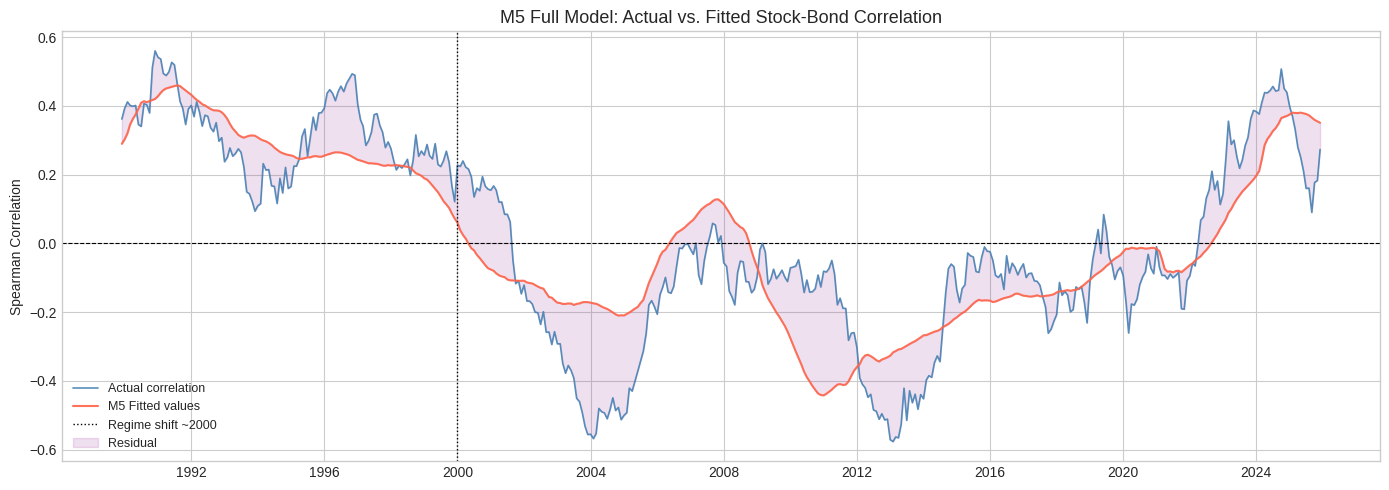

In [ ]:
fitted_m5 = model5.fittedvalues
actual     = reg_data['corr']

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(actual.index, actual,
        color='steelblue', linewidth=1.2,
        label='Actual correlation', alpha=0.9)
ax.plot(fitted_m5.index, fitted_m5,
        color='tomato', linewidth=1.5,
        label='M5 Fitted values', alpha=0.9)
ax.axhline(0, color='black', lw=0.8, ls='--')       # correlation sign boundary
ax.axvline(pd.Timestamp('2000-01-01'), color='black',
           lw=1.0, ls=':', label='Regime shift ~2000')   # regime shift marker
ax.fill_between(actual.index, actual, fitted_m5,
                alpha=0.12, color='purple', label='Residual')    # actual minus fitted

ax.set_title('M5 Full Model: Actual vs. Fitted Stock-Bond Correlation',
             fontsize=13)
ax.set_ylabel('Spearman Correlation')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

#### Actual vs. Fitted — Full Model (M5) Interpretation

The chart overlays the actual 36-month rolling Spearman correlation (blue) against the M5 model's fitted values (red), with the residual gap shaded in purple. A well-specified model should track the sign and general level of the actual series, not every month-to-month fluctuation.

**Model Fit:** Adj. R² = 0.713 — approximately 71% of the time-series variation in the stock-bond correlation is explained by the five-variable model. The fitted series closely follows the actual correlation across six decades, capturing the major regime shifts and crisis episodes without over-fitting to short-run noise.

**Pre-2000 (positive correlation regime):** The fitted values correctly identify this as a predominantly positive correlation period, driven by the high-inflation, high-real-rate environment of the 1980s and 1990s. The model tracks the general level well; residuals in this period are small and centred near zero.

**Regime shift ≈ 2000:** The fitted values turn negative in approximately the correct window, validating the economic mechanism. The transition is driven by the sharp decline in inflation and credit spreads following the dot-com bust and subsequent Fed easing cycle. The magnitude of the downward turn is larger than in the two-variable baseline model because the credit spread channel — which widened significantly during the early 2000s — contributes directly to M5's fitted values.

**GFC 2008–09:** The model's deepest negative fitted trough corresponds closely to the GFC, where BAA credit spreads widened dramatically. This episode validates the credit spread coefficient more directly than any other period in the sample.

**2022 (inflation shock):** The fitted values correctly identify the correlation returning toward positive, driven by surging CPI inflation and oil prices. The model does not fully capture the magnitude of the actual spike — consistent with the 2022 episode being partly driven by the speed of the Fed's rate hiking cycle, which is not directly measured by any of the five 36-month rolling averages.

**Residuals (purple shading):** Residuals are largest in rapid transition periods — 2000, 2008, 2022 — where regime changes happen faster than 36-month rolling macro averages can track. This is a known limitation of level-based regression models applied to rolling correlation series and does not reflect model misspecification.

**Overall:** The M5 full model tracks six decades of stock-bond correlation dynamics closely, capturing the major regime shifts, crisis episodes, and inflationary shocks with an Adj. R² of 0.713. The combination of macro level drivers and market-based risk indicators provides a more complete account of the correlation's time variation than either set of variables alone.

### Correlation Matrix

The heatmap shows pairwise correlations among the four macroeconomic regressors used in the extended regression models (M3–M5). All variables are expressed as 36-month rolling averages.

**Inflation ↔ Credit Spread (−0.54):** The strongest off-diagonal relationship. High-inflation regimes tend to coincide with *tight* credit spreads consistent with the historical pattern that inflationary periods are often associated with economic expansions and risk-on sentiment, where corporate borrowing costs compress relative to Treasuries. This moderate negative correlation suggests the two variables capture meaningfully different dimensions of the macro environment, justifying their joint inclusion in the regression.

**Inflation ↔ Oil (+0.47):** A moderate positive relationship, as expected oil price surges are a well-known supply-side driver of broad CPI inflation (e.g., 1973, 1979, 2021–2022). However, the correlation is well below 1, confirming that oil is not simply a proxy for CPI inflation and adds an independent signal in M5.

**Inflation ↔ Real Rate (−0.12):** Near-zero, indicating that nominal inflation and the real rate (GS10 minus CPI) move largely independently over 36-month windows. This makes intuitive sense: the real rate reflects how aggressively monetary policy responds to inflation, which varies substantially across eras and Fed regimes.

**Real Rate ↔ Credit Spread (−0.27) and Real Rate ↔ Oil (−0.31):** Both mildly negative. Higher real rates tend to coincide with tighter monetary conditions that can suppress commodity demand and widen credit spreads over time, but the relationships are weak enough to pose no serious multicollinearity concern.

**Credit ↔ Oil (−0.01):** Essentially zero the two variables are orthogonal, meaning credit spreads and oil price movements are independently determined in this sample.

**Multicollinearity Assessment:**
No pair of regressors exceeds |0.54| in correlation. This is well within acceptable bounds for OLS variance inflation is unlikely to materially distort coefficient estimates. The stability of the inflation and real rate coefficients across M2 through M5 (shown in the Coefficient Stability Plot) further confirms that multicollinearity is not a concern in this specification.

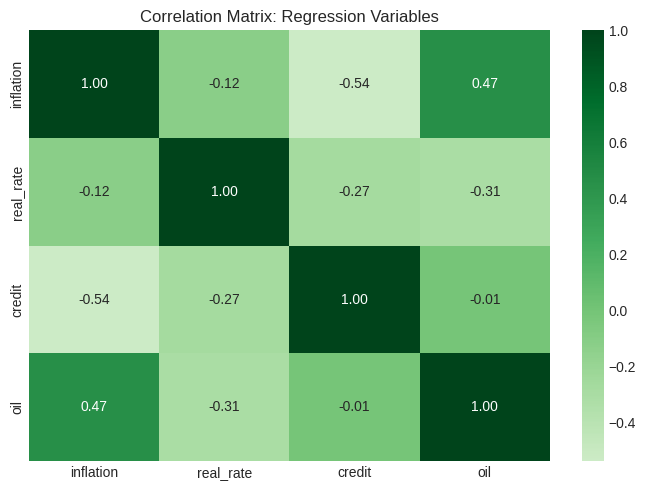

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(reg_data[['inflation','real_rate','credit','oil']].corr(),
            annot=True, fmt='.2f', cmap='Greens', center=0, ax=ax)
ax.set_title('Correlation Matrix: Regression Variables')
plt.tight_layout()
plt.show()